---
title: "Chapter 12: Feature Importances and Model Interpretation"
---

::: {.callout-lo}
By the end of this chapter, you will be able to:

- Distinguish feature–target associations, global model importance, and explanations of individual predictions.
- Interpret linear-model coefficients for scaled numeric, ordinal, and one-hot encoded features.
- Calculate and compare impurity-based and permutation feature importances.
- Read SHAP waterfall, beeswarm, and bar plots, identifying the reference value and output scale.
- Explain how correlated features and preprocessing choices affect interpretation.
- Use explanations to investigate model behaviour without treating them as causal evidence.
:::

## Why look beyond predictive performance?

In Chapter 11, we combined models to improve predictions. But does strong predictive performance tell us enough to trust a model's use?

::: {.callout-reflection}
Suppose a classifier achieves 98% cross-validation accuracy and 97% test accuracy. Assume the evaluation was appropriate, the data represent the intended prediction setting, and these scores substantially beat a simple baseline.

A teammate says, “It predicts well on new examples. We can use it without investigating why it makes its predictions.”

How comfortable would you be with that decision in each situation?

| Scenario | How the prediction is used |
|---|---|
| Photo organization | Suggests labels for personal photos that users can easily correct. |
| Health screening | Flags patients for further testing, with a clinician reviewing the recommendation. |
| Loan applications | Automatically rejects applications predicted to be unlikely to repay. |

What could go wrong despite the strong score? Who might need an explanation, and why? Would an explanation address your concern, or would you need other evidence?
:::

The consequences of errors and opportunities for review differ. Explaining every photo label may offer little benefit, while a clinician may want to check which measurements contributed to a recommendation. An applicant may need to understand and challenge a loan rejection. Overall accuracy alone does not answer these needs.

**Model interpretation** helps us investigate how a fitted model produces predictions. It can reveal unexpected dependencies and help us communicate model behaviour. But a plausible explanation does not establish accuracy, fairness, or suitability for use; those require additional evidence.


To investigate a model’s behaviour, we first need to be clear about what we want to explain. Are we asking about relationships in the data, the model’s overall behaviour, or one particular prediction? Different approaches answer different questions.

| Question | Example | Starting approach |
|---|---|---|
| How is a feature associated with the target in the data? | Do larger houses tend to sell for more? | Correlations and plots |
| How does a fitted model use its inputs overall? | Which property measurements does this model rely on? | Coefficients, tree importance, permutation importance |
| What contributed to one prediction? | Why is the predicted price for this house above the reference value? | Local contributions, such as SHAP values |

A **global explanation** summarizes model behaviour across examples. A **local explanation** concerns a particular prediction. A feature that matters little on average can still contribute substantially to one unusual prediction.

Throughout the chapter, keep this distinction in mind: **explaining the model is not the same as explaining how the world works**. Changing a house's recorded quality rating and recomputing a prediction tells us about the model. It does not tell us what a renovation would do to the eventual sale price.

We will first return to the housing data from Chapter 10, where changes in predicted dollars make coefficients concrete. We will then use the Adult income task from Chapter 11 to investigate tree models and individual predictions. Both examples run independently of the earlier notebooks.


In [1]:
#| code-fold: true
#| code-summary: "Show imports and setup"
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import make_column_transformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from lightgbm import LGBMClassifier
import shap

%matplotlib inline
DATA_DIR = Path("data")
plt.rcParams.update({"figure.figsize": (8, 4)})

## Correlations: a starting point

We use the housing data and preprocessing decisions from Chapter 10: preserve `None` as a category, distinguish absent amenities from unknown descriptions, scale numeric and ordinal features, and one-hot encode the remaining categories. The target remains the price in dollars; we do not log-transform it here.

The setup below repeats those decisions so you can run this chapter on its own. As before, the labelled housing file belongs in `data/housing-kaggle/train.csv`. We reserve the same test split and leave it aside. The examples that change a house's inputs use training rows to inspect the fitted prediction rule, not to estimate performance on new houses.

In [2]:
#| code-fold: true
#| code-summary: "Show housing data and preprocessing from Chapter 10"
df = pd.read_csv(
    DATA_DIR / "housing-kaggle/train.csv",
    keep_default_na=False,
    na_values=["", "NA"],
)
train_df, test_df = train_test_split(df, test_size=0.10, random_state=123)


X_train = train_df.drop(columns=["SalePrice"])
y_train = train_df["SalePrice"]

X_test = test_df.drop(columns=["SalePrice"])
y_test = test_df["SalePrice"]



def mark_absent_amenities(X):
    X = X.copy()
    amenity_columns = {
        "TotalBsmtSF": ["BsmtQual", "BsmtCond", "BsmtExposure",
                        "BsmtFinType1", "BsmtFinType2"],
        "Fireplaces": ["FireplaceQu"],
        "GarageArea": ["GarageType", "GarageFinish", "GarageQual", "GarageCond"],
        "PoolArea": ["PoolQC"],
    }
    for measurement, columns in amenity_columns.items():
        absent = X[measurement].eq(0)
        X.loc[absent, columns] = X.loc[absent, columns].fillna("Absent")

    for column in ["Alley", "Fence", "MiscFeature"]:
        X[column] = X[column].fillna("Absent")
    return X


X_train = mark_absent_amenities(X_train)
X_test = mark_absent_amenities(X_test)


drop_features = ["Id"]
numeric_features = [
    "BedroomAbvGr",
    "KitchenAbvGr",
    "LotFrontage",
    "LotArea",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "YearRemodAdd",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "BsmtFullBath",
    "BsmtHalfBath",
    "FullBath",
    "HalfBath",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "MiscVal",
    "YrSold",
]

ordinal_features_reg = ["ExterQual", "ExterCond", "HeatingQC", "KitchenQual"]
ordering = ["Po", "Fa", "TA", "Gd", "Ex"]
ordering_ordinal_reg = [ordering] * len(ordinal_features_reg)

ordinal_features_oth = ["Functional"]
ordering_ordinal_oth = [
    ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
]

assigned_features = (
    drop_features + numeric_features + ordinal_features_reg + ordinal_features_oth
)
categorical_features = [
    column for column in X_train.columns if column not in assigned_features
]

numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True),
    StandardScaler(),
)
ordinal_transformer_reg = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(categories=ordering_ordinal_reg),
    StandardScaler(),
)
ordinal_transformer_oth = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(categories=ordering_ordinal_oth),
    StandardScaler(),
)
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="Unknown"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

preprocessor = make_column_transformer(
    ("drop", drop_features),
    (numeric_transformer, numeric_features),
    (ordinal_transformer_reg, ordinal_features_reg),
    (ordinal_transformer_oth, ordinal_features_oth),
    (categorical_transformer, categorical_features),
    verbose_feature_names_out=False,
)

Before fitting a model, consider a simpler question: do houses with higher quality ratings tend to sell for more? **Pearson correlation** measures the direction and strength of a linear association. Values near +1 indicate a strong positive linear association; values near −1 indicate a strong negative one. A value near zero indicates little linear association, not necessarily an absence of any relationship.

We inspect a few training columns rather than a heatmap of every encoded feature. These correlations use observed pairs of values and are descriptions of the data, not explanations of a fitted model.

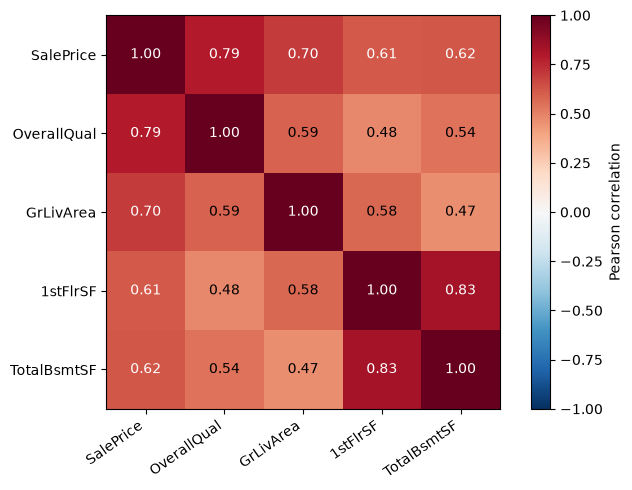

In [3]:
corr_columns = ["SalePrice", "OverallQual", "GrLivArea", "1stFlrSF", "TotalBsmtSF"]
corr = train_df[corr_columns].corr()
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)), corr.columns, rotation=35, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
for row in range(len(corr)):
    for col in range(len(corr)):
        ax.text(col, row, f"{corr.iloc[row, col]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[row, col]) > 0.6 else "black")
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

`OverallQual` and `GrLivArea` are positively associated with sale price. That makes them worth investigating, but correlation only examines two variables at a time. It does not tell us how a model combines them or whether one supplies information already available in other columns.

Also notice the association between first-floor area (`1stFlrSF`) and basement area (`TotalBsmtSF`). If a model relies heavily on one, it may have less need for the other. An importance ranking therefore depends partly on which other features are available.

Correlation can also miss a non-linear relationship. Suppose houses near a busy commercial centre have lower prices because of traffic and noise, houses a little farther away are more expensive, and very remote houses are cheaper again because of long commutes. In this hypothetical example, distance could help predict price even if its Pearson correlation with price is near zero: the relationship rises and then falls, rather than following a straight line.


## Interpreting linear-model coefficients

Recall the prediction rule for linear regression:

$$\hat{y} = b + \sum_{j=1}^{p} w_j z_j.$$

Here, $z_j$ is a **transformed input**, $w_j$ is its coefficient, and $b$ is the intercept. If we increase just $z_j$ by one, the prediction changes by $w_j$. This is an exact statement about the fitted linear model. The harder part is translating a change in the original input into a change in $z_j$.

We fit ridge regression with `alpha=100`, a fixed demonstration setting rather than the result of a new search. First, compare it with a baseline using cross-validation. Preprocessing is fitted within each fold. A weak model can still be inspected to diagnose mistakes, but its coefficients should not be treated as strong evidence about useful predictive relationships.

In [4]:
house_pipe = make_pipeline(clone(preprocessor), Ridge(alpha=100))
house_scores = {}
for name, estimator in {
    "Predict training mean": DummyRegressor(),
    "Ridge": house_pipe,
}.items():
    scores = cross_validate(estimator, X_train, y_train, cv=5, scoring="r2")
    house_scores[name] = {
        "Mean validation R2": scores["test_score"].mean(),
        "SD across folds": scores["test_score"].std(),
    }
pd.DataFrame(house_scores).T

,Mean validation R2,SD across folds
Predict training mean,-0.005307,0.005636
Ridge,0.797221,0.097971


The ridge model improves on predicting a constant, although its validation performance varies across folds. That gives us context for inspecting its prediction rule; it does not make every learned association reliable.

Now fit on the full training split and recover the feature names from **this fitted pipeline**. Matching the names to the coefficient order is essential. A separate preprocessor fitted on different data could produce different columns.

In [5]:
house_pipe.fit(X_train, y_train)
house_preprocessor = house_pipe.named_steps["columntransformer"]
house_coefs = pd.Series(
    house_pipe.named_steps["ridge"].coef_,
    index=house_preprocessor.get_feature_names_out(),
    name="Coefficient",
)
house_coefs.reindex(house_coefs.abs().sort_values(ascending=False).index).head(10)

OverallQual             14071.079678
GrLivArea               11501.817023
BsmtQual_Ex             11170.908367
Neighborhood_NoRidge     9373.965731
Neighborhood_NridgHt     8397.405152
GarageCars               8262.693270
2ndFlrSF                 8075.399323
BsmtExposure_Gd          7305.454377
Condition1_Norm          7145.332642
1stFlrSF                 6681.399715
Name: Coefficient, dtype: float64

This table is a starting point, not a ranking of the intrinsic usefulness of the original features. Some columns are standardized measurements, some are standardized ordinal codes, and others are 0/1 indicators. Their coefficients refer to different kinds of changes. Let’s interpret one of each.

### Scaled numeric features

Suppose our fitted scaler uses a standard deviation of 2,000 square feet for lot area, and the model’s coefficient for standardized lot area is \$10,000. These are illustrative numbers; we will inspect our fitted model below. What does this coefficient mean?

Increasing lot area by 2,000 square feet increases the standardized input by one. Holding the other inputs fixed, the model therefore predicts a \$10,000 increase in price. An increase of 1,000 square feet is half as large, so the predicted increase is \$5,000.

| Increase in lot area | Increase after scaling | Change in predicted price |
|---|---|---|
| 2,000 square feet | 1 | \$10,000 |
| 1,000 square feet | 0.5 | \$5,000 |
| 1 square foot | 1/2,000 | \$5 |

The coefficient describes a one-training-standard-deviation increase in area, not one square foot. To express the predicted change per square foot, divide the coefficient by the fitted scale.

Let’s apply the same reasoning to our housing model. We need two numbers: the coefficient for `LotArea` and the scale used to standardize it. The output below also shows their ratio: the predicted change in dollars per additional square foot, holding other inputs fixed.


In [6]:
#| code-fold: true
#| code-summary: "Show how to retrieve the fitted scale"

numeric_branch = house_preprocessor.named_transformers_["pipeline-1"]
numeric_names = numeric_branch.named_steps["simpleimputer"].get_feature_names_out(numeric_features)
numeric_scales = pd.Series(
    numeric_branch.named_steps["standardscaler"].scale_, index=numeric_names
)
area_scale = numeric_scales["LotArea"]
area_coef = house_coefs["LotArea"]
pd.Series({
    "Training scale in square feet": area_scale,
    "Dollars per scaled unit": area_coef,
    "Dollars per additional square foot": area_coef / area_scale,
})

Training scale in square feet         8994.471032
Dollars per scaled unit               3421.864806
Dollars per additional square foot       0.380441
dtype: float64

Let’s check this interpretation by adding 1,000 square feet to a recorded lot area while leaving the other inputs fixed. First divide 1,000 by `area_scale` to find the increase in standardized units, then multiply by `area_coef`. We compare that calculation with predictions from the complete pipeline.


In [7]:
house = X_train.loc[X_train["LotArea"].notna()].iloc[[0]].copy()
larger_lot = house.copy()
larger_lot["LotArea"] += 1000
area_expected = area_coef * 1000 / area_scale
area_actual = (house_pipe.predict(larger_lot) - house_pipe.predict(house))[0]
np.testing.assert_allclose(area_actual, area_expected)
pd.Series({"Change from coefficient ($)": area_expected,
           "Change from predictions ($)": area_actual})

Change from coefficient ($)    380.440917
Change from predictions ($)    380.440917
dtype: float64

The two calculations agree. We can summarize the steps with a general rule:

$$\text{change in prediction} = \text{coefficient}\times\frac{\text{change in original input}}{\text{fitted scale}}.$$

Recall that standard scaling subtracts the training mean and divides by the fitted scale. When comparing two input values, the same mean is subtracted from both, so it cancels out. Only the division affects the size of the change.

This is a statement about changing a model input while holding the other inputs fixed. Real houses with larger lots may also differ in neighbourhood, floor area, and other characteristics. The calculation does not isolate the causal value of land.

### Ordinal features

`ExterQual` uses the order Poor, Fair, Typical, Good, Excellent. As in Chapter 10, we encode these levels as consecutive integers **and then standardize them**. Moving from Good to Excellent changes the unscaled code by one, so the predicted change is the coefficient divided by the ordinal feature's fitted scale.

For a linear model, consecutive codes impose the same predicted change for every adjacent pair of levels. Scaling does not remove that equal-spacing assumption. It is a modelling choice, not a fact established by the labels.

In [8]:
ordinal_scale = pd.Series(
    house_preprocessor.named_transformers_["pipeline-2"].named_steps["standardscaler"].scale_,
    index=ordinal_features_reg,
)
good_house = X_train.loc[X_train["ExterQual"].eq("Gd")].iloc[[0]].copy()
excellent_house = good_house.copy()
excellent_house["ExterQual"] = "Ex"
quality_expected = house_coefs["ExterQual"] / ordinal_scale["ExterQual"]
quality_actual = (house_pipe.predict(excellent_house) - house_pipe.predict(good_house))[0]
np.testing.assert_allclose(quality_actual, quality_expected)
pd.Series({"Change from coefficient ($)": quality_expected,
           "Change from predictions ($)": quality_actual})

Change from coefficient ($)    9700.424021
Change from predictions ($)    9700.424021
dtype: float64

Again, the prediction difference matches the calculation. We have checked how the model responds to an edited rating. We have not estimated the return on a renovation, which could change several features and would require a different kind of evidence.

### One-hot encoded features

`LandSlope` has categories Gentle (`Gtl`), Moderate (`Mod`), and Severe (`Sev`). We kept all three one-hot columns. Switching from Gentle to Moderate changes **two** inputs: `LandSlope_Gtl` goes from 1 to 0, and `LandSlope_Mod` goes from 0 to 1. The predicted change is therefore

$$w_{\text{LandSlope\_Mod}} - w_{\text{LandSlope\_Gtl}}.$$

Reading the Moderate coefficient alone as a price difference from Gentle would be incorrect. Let’s put the coefficients beside their differences from Gentle.

In [9]:
slope_coefs = house_coefs[house_coefs.index.str.startswith("LandSlope_")]
pd.DataFrame({
    "Coefficient": slope_coefs,
    "Difference from Gentle ($)": slope_coefs - slope_coefs["LandSlope_Gtl"],
})

,Coefficient,Difference from Gentle ($)
LandSlope_Gtl,-2365.345172,0.000000
LandSlope_Mod,3174.619024,5539.964196
LandSlope_Sev,-809.273853,1556.071319


In [10]:
gentle_house = X_train.loc[X_train["LandSlope"].eq("Gtl")].iloc[[0]].copy()
moderate_house = gentle_house.copy()
moderate_house["LandSlope"] = "Mod"
slope_expected = slope_coefs["LandSlope_Mod"] - slope_coefs["LandSlope_Gtl"]
slope_actual = (house_pipe.predict(moderate_house) - house_pipe.predict(gentle_house))[0]
np.testing.assert_allclose(slope_actual, slope_expected)
pd.Series({"Change from coefficients ($)": slope_expected,
           "Change from predictions ($)": slope_actual})

Change from coefficients ($)    5539.964196
Change from predictions ($)     5539.964196
dtype: float64

If an encoder drops a reference category, its remaining coefficients describe differences from that omitted category, holding other transformed inputs fixed. With all categories retained, use coefficient differences for category switches. Changing the encoding and refitting a regularized model can also change its predictions; it is not necessarily just a relabelling of the coefficients.

### When coefficients are difficult to interpret

Correlated features do not prevent us from calculating a linear model's response to an input change. They do make it harder to attribute a predictive relationship to one feature. Different fitted models may distribute weight differently among related columns while producing similar predictions. A surprising sign is a reason to investigate, not immediate proof of a data error.

Scaling makes units more comparable, but it does not turn coefficient magnitudes into universal importance scores. A one-standard-deviation change is different from switching a binary indicator, and the distribution of actual feature values matters. Regularization and the set of included features also affect the learned coefficients. The scikit-learn example on [coefficient interpretation](https://scikit-learn.org/stable/auto_examples/inspection/plot_linear_model_coefficient_interpretation.html) explores these issues in more detail.

### Exercise 12.1: Read the preprocessing first

A ridge model predicts price in dollars. Its coefficient for standardized floor area is 30,000, and the fitted area scale is 500 square feet. Its unscaled one-hot coefficients for neighbourhoods A and B are 8,000 and −2,000.

1. What change does the model predict for an additional 100 square feet, holding other inputs fixed?
2. What change does it predict when switching from neighbourhood A to B?
3. A classmate calls the first answer “the amount a 100-square-foot extension will add to the sale price.” What is missing from that claim?

::: {.callout-tip collapse="true" title="Solution"}
1. $30{,}000\times100/500=6{,}000$: the prediction increases by \$6,000.
2. $-2{,}000-8{,}000=-10{,}000$: the prediction decreases by \$10,000.
3. We calculated changes in this fitted model, not causal effects. An extension may change other characteristics, and the observational training data do not establish what the same house would sell for with and without that extension.
:::

## Feature importance beyond linear models

The housing example let us read a prediction rule directly. A forest has many trees, and a boosted model combines many successive corrections. There is no single coefficient per feature to inspect. We need a different way to summarize how these models use their inputs.

We return to the historical Adult income dataset from Chapter 11, predicting whether recorded annual income exceeds \$50,000. We retain its preprocessing choices, including the education order and dropped columns. Dropping `race` does not remove information about race from other features or establish fairness; this remains an instructional prediction exercise.

We reserve the same test split as Chapter 11, then divide the remaining rows into fitting and validation sets. The validation set will support performance checks, permutation importance, and SHAP examples. If those investigations lead to model changes, the test set is still available for a final evaluation. The smaller fitting set means the results need not match Chapter 11.

In [11]:
#| code-fold: true
#| code-summary: "Show Adult splits and preprocessing"

adult = pd.read_csv(DATA_DIR / "adult.csv")
adult_development, adult_test = train_test_split(adult, test_size=0.2, random_state=42)
adult_fit, adult_valid = train_test_split(
    adult_development, test_size=0.25, random_state=123,
    stratify=adult_development["income"],
)
adult_fit = adult_fit.replace("?", np.nan)
adult_valid = adult_valid.replace("?", np.nan)

numeric_features = ["age", "capital.gain", "capital.loss", "hours.per.week"]

categorical_features = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "native.country",
]

ordinal_features = ["education"]
binary_features = ["sex"]
drop_features = ["fnlwgt", "race", "education.num"]
target_column = "income"
education_levels = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate",
]
numeric_transformer = StandardScaler()

ordinal_transformer = OrdinalEncoder(categories=[education_levels], dtype=int)

binary_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    OneHotEncoder(drop="if_binary", dtype=int),
)
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

adult_preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (ordinal_transformer, ordinal_features),
    (binary_transformer, binary_features),
    (categorical_transformer, categorical_features),
    ("drop", drop_features),
    verbose_feature_names_out=False,
)

assert set(adult_fit["income"]) == {"<=50K", ">50K"}
X_adult_fit = adult_fit.drop(columns="income")
X_adult_valid = adult_valid.drop(columns="income")
y_adult_fit = adult_fit["income"].eq(">50K").astype(int)
y_adult_valid = adult_valid["income"].eq(">50K").astype(int)

We fit three familiar models with fixed settings: logistic regression, a random forest, and LightGBM. Each gets its own cloned preprocessor, so fitting one pipeline cannot change another's fitted transformations. We include a majority-class baseline and use accuracy for continuity with Chapter 11. The interpretation will be tied to that metric; accuracy is not automatically the right choice for another application.

In [12]:
adult_models = {
    "Logistic regression": make_pipeline(
        clone(adult_preprocessor), LogisticRegression(max_iter=2000)
    ),
    "Random forest": make_pipeline(
        clone(adult_preprocessor),
        RandomForestClassifier(n_estimators=100, random_state=123, n_jobs=1),
    ),
    "LightGBM": make_pipeline(
        clone(adult_preprocessor),
        LGBMClassifier(random_state=123, verbosity=-1, n_jobs=1),
    ),
}
baseline = DummyClassifier(strategy="most_frequent").fit(X_adult_fit, y_adult_fit)
adult_scores = {"Majority class": {
    "Training accuracy": baseline.score(X_adult_fit, y_adult_fit),
    "Validation accuracy": baseline.score(X_adult_valid, y_adult_valid),
}}
for name, pipe in adult_models.items():
    pipe.fit(X_adult_fit, y_adult_fit)
    adult_scores[name] = {
        "Training accuracy": pipe.score(X_adult_fit, y_adult_fit),
        "Validation accuracy": pipe.score(X_adult_valid, y_adult_valid),
    }
pd.DataFrame(adult_scores).T.round(3)

,Training accuracy,Validation accuracy
Majority class,0.758,0.758
Logistic regression,0.855,0.853
Random forest,0.978,0.852
LightGBM,0.889,0.869


Read the training–validation gap as well as the validation score. A model may use a feature to fit training examples without gaining useful predictive information for new examples. This distinction will matter when we compare importance methods.

### A brief return to logistic regression

For binary logistic regression, coefficients act on the **log-odds** of the positive class, not directly on its probability. Here the positive class is `>50K`, encoded as 1. Holding other transformed inputs fixed, a positive coefficient increases its log-odds and therefore its probability. The probability change depends on the starting prediction; it is not the coefficient itself.

As in the housing example, read the preprocessing first. Numeric features are standardized, education is ordinal encoded without scaling, and categorical inputs use indicators. For example, a coefficient for `age` refers to a one-training-standard-deviation increase, while the education coefficient refers to one step in its encoded order.

In [13]:
adult_lr = adult_models["Logistic regression"]
adult_lr_coefs = pd.Series(
    adult_lr.named_steps["logisticregression"].coef_[0],
    index=adult_lr.named_steps["columntransformer"].get_feature_names_out(),
    name="Log-odds coefficient",
)
adult_lr_coefs.reindex(adult_lr_coefs.abs().sort_values(ascending=False).index).head(8)

capital.gain                        2.305364
marital.status_Married-AF-spouse    1.876896
occupation_Priv-house-serv         -1.540356
marital.status_Never-married       -1.426234
relationship_Own-child             -1.333088
native.country_Columbia            -1.174423
native.country_Greece              -1.090200
relationship_Wife                   1.006413
Name: Log-odds coefficient, dtype: float64

### Impurity-based importance in trees

Recall that a classification tree chooses splits that separate the classes. A useful split reduces the mixture of classes in its child nodes. **Impurity-based importance** credits each feature for these reductions, weighting splits by the number of training examples reaching them. A forest combines the contributions across its trees.

Scikit-learn exposes this measure as `feature_importances_`. For the fitted forest below, the importances are non-negative and sum to one. They summarize how the trees were built; they do not indicate whether increasing a feature raises or lowers a prediction.

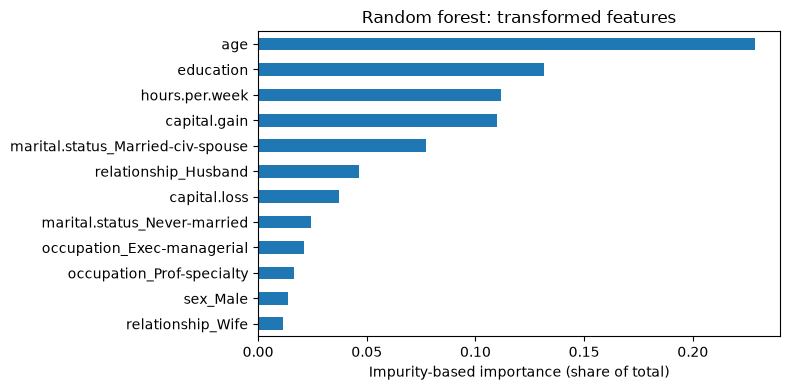

In [14]:
forest_pipe = adult_models["Random forest"]
forest_names = forest_pipe.named_steps["columntransformer"].get_feature_names_out()
impurity_importance = pd.Series(
    forest_pipe.named_steps["randomforestclassifier"].feature_importances_,
    index=forest_names,
).sort_values()
impurity_importance.tail(12).plot.barh()
plt.xlabel("Impurity-based importance (share of total)")
plt.title("Random forest: transformed features")
plt.tight_layout()
plt.show()

In this forest, `age` has the largest impurity-based importance, followed by `education`. Each bar corresponds to a transformed column. An original category such as occupation is spread across several indicators, so its individual bars are not directly comparable to a numeric feature represented by one column.

There are also statistical limitations. This measure uses training splits and can reward overfitting. Features with many possible split points have more opportunities to produce a favourable split. See the [scikit-learn discussion of impurity-based importance](https://scikit-learn.org/stable/modules/permutation_importance.html#relation-to-impurity-based-importance-in-trees). We would like a complementary question: does disrupting this feature hurt predictions on held-out examples?

### Permutation importance

Imagine shuffling the `age` values among validation rows while leaving the other columns and labels in place. The model can still make predictions, but age is no longer correctly matched to each person. If accuracy falls, that is evidence that the fitted model relied on the original age information for this evaluation.

**Permutation importance** measures the decrease in a chosen score after shuffling one feature. The model is not refitted. We repeat the shuffle to see how much the result varies with the permutation. For accuracy,

$$\text{importance} = \text{original accuracy} - \text{accuracy after shuffling}.$$

This method is **model agnostic**: it needs predictions and a scoring rule, rather than access to tree splits or coefficients. We can apply the same procedure to the forest and to LightGBM.

We pass the complete pipeline and the original columns. This shuffles a categorical variable before encoding, keeping its one-hot indicators consistent. Shuffling each indicator independently could create impossible combinations, such as a row assigned to several occupations at once.

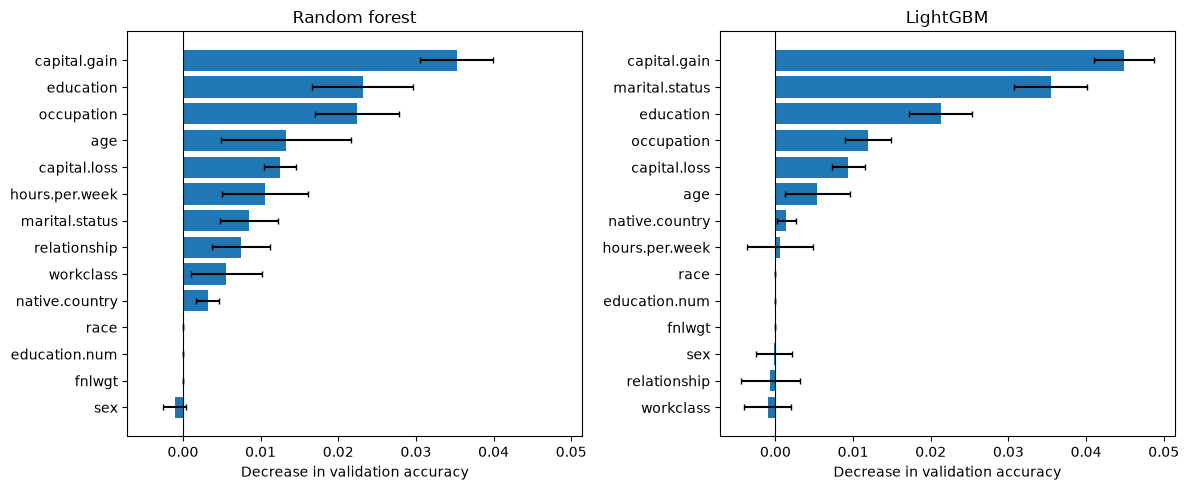

In [15]:
# Use a reproducible validation subset to keep repeated scoring manageable.
X_inspect = X_adult_valid.sample(n=min(1500, len(X_adult_valid)), random_state=123)
y_inspect = y_adult_valid.loc[X_inspect.index]
permutation_results = {}
for name in ["Random forest", "LightGBM"]:
    permutation_results[name] = permutation_importance(
        adult_models[name], X_inspect, y_inspect,
        scoring="accuracy", n_repeats=10, random_state=123, n_jobs=1,
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
for ax, (name, result) in zip(axes, permutation_results.items()):
    order = result.importances_mean.argsort()
    ax.barh(X_inspect.columns[order], result.importances_mean[order],
            xerr=result.importances_std[order], capsize=2)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel("Decrease in validation accuracy")
plt.tight_layout()
plt.show()

Here, shuffling `capital.gain` produces the largest mean decrease for both models. The forest’s impurity ranking put `age` first, so the methods are already giving us different views of the same fitted forest.

A decrease of 0.02 means **two percentage points of accuracy**, not a 2% change in a person's predicted probability. Larger positive values indicate greater reliance under this experiment. A value near zero means little measured change for this model, metric, and sample. A negative value means the score improved after shuffling; small negative values can arise from random variation and do not describe a negative relationship with the target.

The error bars show one standard deviation across shuffles. They do not measure all uncertainty: changing the fitting data, validation sample, or model settings may change the ranking too. The dropped columns have zero importance because the pipeline never passes them to the classifier.

Notice that the permutation plots use **original features**, whereas the impurity plot uses transformed columns. Their numerical scales and units also differ. Compare the questions they answer, not just the lengths of bars.

Correlated inputs need special care. If a model uses two features carrying similar information, shuffling one may leave enough information in the other that performance changes little. Shuffling can also produce unusual combinations of inputs. A low importance is therefore not proof that a feature is inherently useless. The [scikit-learn correlated-features example](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html) illustrates this problem.

### Exercise 12.2: Can we remove both features?

A model predicts well on validation data. Two strongly related measurements each have permutation importance near zero. A colleague recommends deleting both without another evaluation.

1. Why might the individual importances be small?
2. What experiment would you run before accepting the recommendation?
3. Would a large impurity-based importance for one measurement settle the question?

::: {.callout-tip collapse="true" title="Solution"}
1. The model may use overlapping information from the two measurements, so disrupting just one has little effect. Other explanations, including the selected metric or sample, are also possible.
2. Compare pipelines refitted with one measurement removed and with both removed, using validation data or cross-validation. Jointly shuffling both with the same row permutation can also investigate reliance on the pair, but it does not replace evaluating a refitted model.
3. No. Impurity importance describes training splits. The practical question is whether removing the feature harms the performance of the resulting model on held-out data.
:::

## Explaining individual predictions with SHAP

The importance plots summarize model behaviour across rows. Suppose instead we want to inspect why one person receives a high predicted probability of income above \$50,000. A global ranking cannot tell us which values contributed to that particular prediction.

For a linear model, we can directly examine weighted input values. For a more complex model, **SHAP** provides a way to allocate the difference between a reference output and an individual model output among the features:

$$f(x) = \text{base value} + \sum_{j=1}^{p}\phi_j(x).$$

Here, $f(x)$ is the output we are explaining and $\phi_j(x)$ is the SHAP contribution assigned to feature $j$ for example $x$. A positive contribution pushes the explained output above the reference; a negative one pushes it below. The same feature can have contributions with different signs for different examples.

The idea comes from **Shapley values** in game theory. Imagine sharing a team's total reward by asking how much each player adds when joining different subsets of the team. In a prediction explanation, the features play the role of the players. SHAP averages contributions over different combinations of available features, using a specified way to represent the unavailable information. We will focus on using and interpreting the explanations rather than deriving the algorithm.

The reference and the treatment of unavailable features matter, especially when inputs are related. SHAP is not a unique explanation independent of those choices, and the word “contribution” does not mean a causal effect.

### Choose the model, reference data, and output scale

We explain the already fitted LightGBM model. We obtain transformed inputs from its own fitted preprocessor; we do not refit either component. The explainer uses a reproducible sample of 100 fitting rows as **background data**, which defines the reference population for this explanation. We explain 300 validation rows to keep the computation and plots manageable.

We explicitly use `feature_perturbation="interventional"`. In this mode, background rows supply values for missing features without conditioning them on all the observed features. This can break dependencies among features; despite its name, the setting does not establish causal effects. It can also create unrealistic combinations of encoded categories. Keep these limitations in mind when interpreting individual indicator contributions. The [TreeExplainer documentation](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html) describes the available choices.

In [16]:
lgbm_pipe = adult_models["LightGBM"]
lgbm_preprocessor = lgbm_pipe.named_steps["columntransformer"]
lgbm_model = lgbm_pipe.named_steps["lgbmclassifier"]
lgbm_names = lgbm_preprocessor.get_feature_names_out()

def encode_for_lgbm(frame):
    return pd.DataFrame(lgbm_preprocessor.transform(frame),
                        columns=lgbm_names, index=frame.index)

background = encode_for_lgbm(X_adult_fit.sample(n=100, random_state=123))
X_explain_raw = X_adult_valid.sample(n=300, random_state=123)
X_explain = encode_for_lgbm(X_explain_raw)
explainer = shap.TreeExplainer(
    lgbm_model, data=background,
    feature_perturbation="interventional", model_output="raw",
)
shap_values = explainer(X_explain)
shap_values.shape

(300, 84)

There is one contribution per transformed feature per explained row. For this binary LightGBM model, `model_output="raw"` explains the **log-odds of class 1**, not its probability. The base value is the mean raw output over our chosen background sample. It is not the fraction of people with income above \$50,000.

Recall the logistic conversion: if the raw score is $s$, its probability is $1/(1+e^{-s})$. First we check that the base value plus the SHAP contributions reconstructs the raw score, then convert that total to a probability. Converting each contribution separately would not give additive probability contributions.

In [17]:
raw_scores = lgbm_model.predict(X_explain, raw_score=True)
reconstructed_scores = shap_values.base_values + shap_values.values.sum(axis=1)
np.testing.assert_allclose(reconstructed_scores, raw_scores, atol=1e-5)
np.testing.assert_allclose(
    shap_values.base_values, lgbm_model.predict(background, raw_score=True).mean(),
    atol=1e-5,
)
np.testing.assert_allclose(
    1 / (1 + np.exp(-raw_scores)),
    lgbm_pipe.predict_proba(X_explain_raw)[:, 1],
)
pd.DataFrame({
    "Base + contributions": reconstructed_scores,
    "Model raw score": raw_scores,
    "Probability of >50K": lgbm_pipe.predict_proba(X_explain_raw)[:, 1],
}, index=X_explain_raw.index).head()

,Base + contributions,Model raw score,Probability of >50K
15099,-4.318873,-4.318873,0.013140
14468,1.960487,1.960487,0.876586
29983,-7.779282,-7.779282,0.000418
28587,-5.918548,-5.918548,0.002682
32139,-3.078843,-3.078843,0.043988


### Read a waterfall plot

A waterfall plot starts at the base value and adds the feature contributions to reach one model output. We select two illustrative validation rows: the lowest and highest predicted probabilities within our sample. These deliberately contrasting examples help us read the plots; they do not represent typical performance or establish that either prediction is correct.

In [18]:
probabilities = lgbm_pipe.predict_proba(X_explain_raw)[:, 1]
low_position = int(np.argmin(probabilities))
high_position = int(np.argmax(probabilities))
positions = [low_position, high_position]
example_summary = X_explain_raw.iloc[positions][
    ["age", "education", "occupation", "capital.gain", "hours.per.week"]
].copy()
example_summary["Observed class (1 = >50K)"] = y_adult_valid.loc[example_summary.index]
example_summary["Predicted probability of >50K"] = probabilities[positions]
example_summary

,age,education,occupation,capital.gain,hours.per.week,Observed class (1 = >50K),Predicted probability of >50K
22755,17,11th,Adm-clerical,0,16,0,0.000339
1671,38,Masters,Exec-managerial,99999,70,1,0.999016


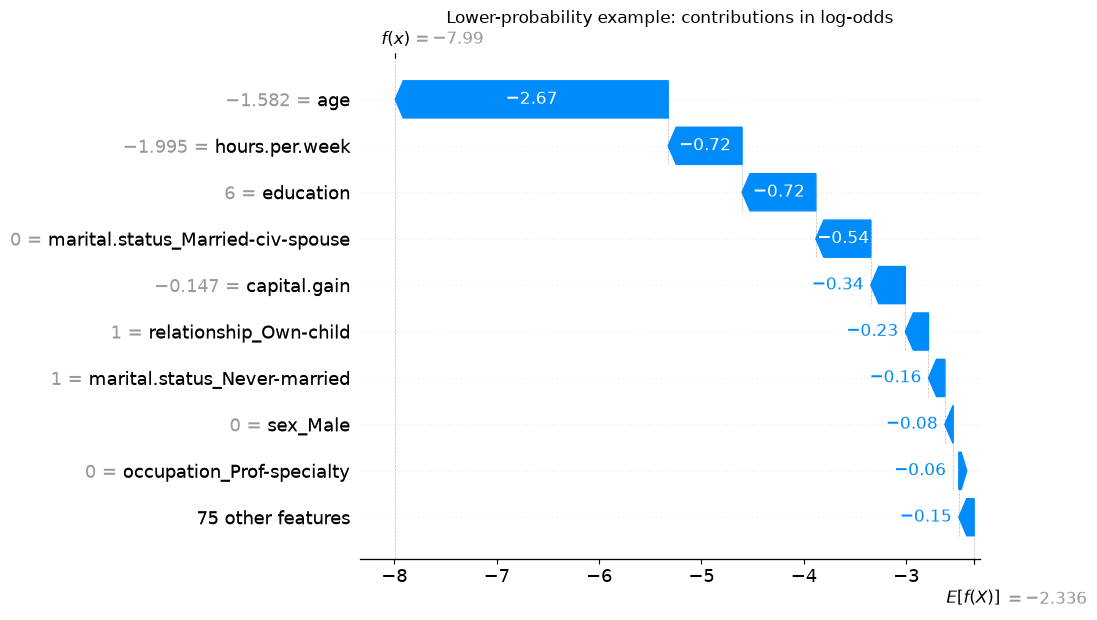

In [19]:
shap.plots.waterfall(shap_values[low_position], max_display=10, show=False)
plt.title("Lower-probability example: contributions in log-odds")
plt.show()

For the lower-probability example, the largest downward contribution is from `age`. The record describes a 17-year-old, while the plotted value is the standardized age.

Read the horizontal axis first: these are log-odds. Red arrows move the output upward from the base; blue arrows move it downward. The final value labelled $f(x)$ is the raw score we reconstructed above. A negative raw score corresponds to a probability below 0.5.

The values beside feature names are the **transformed inputs**. For example, a standardized age of 1 means one fitted standard deviation above the training mean, not an age of one year. A one-hot indicator of 0 means that category is absent, and its absence can still receive a contribution. The small contributions are grouped into a single row to keep the plot readable.

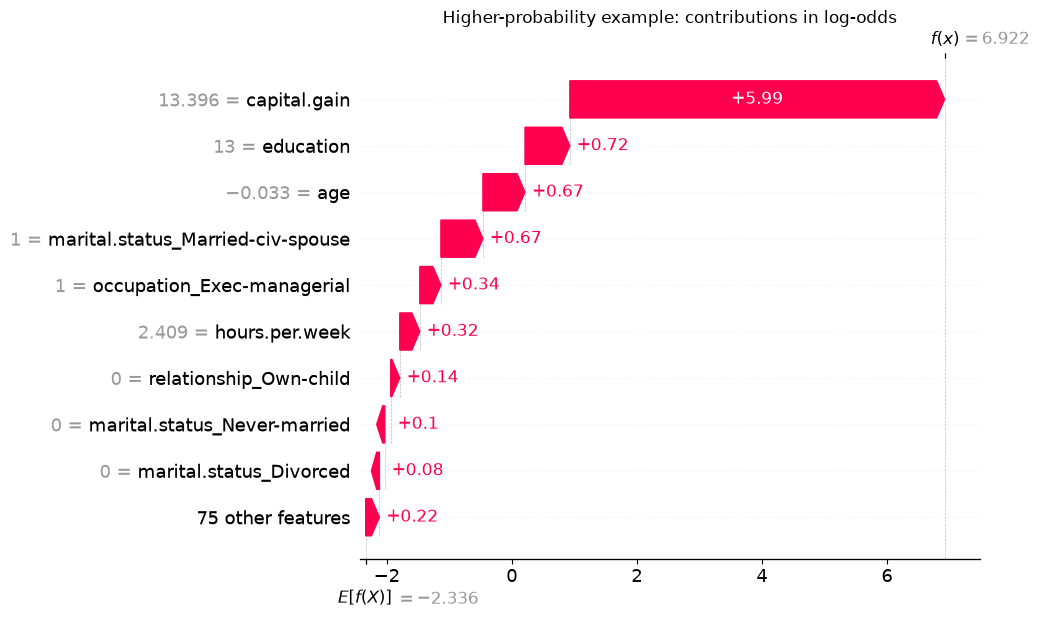

In [20]:
shap.plots.waterfall(shap_values[high_position], max_display=10, show=False)
plt.title("Higher-probability example: contributions in log-odds")
plt.show()

Both plots use the same reference, but their feature values and contributions differ. For the higher-probability example, the recorded capital gain supplies the largest upward contribution. Its prominence differs from the importance of age in the lower-probability example. Look back at the original records and compare them with the transformed values on the plots: the capital gain is in dollars in the table, but standardized units in the plot.

A strong contribution is part of an explanation of this prediction. It is not a recommendation to change that feature, nor does a high predicted probability guarantee the observed outcome.

### From local explanations to global summaries

To summarize many local explanations, we can average the **absolute** SHAP contribution of each transformed feature. Absolute values prevent positive and negative contributions from cancelling. The resulting bar chart measures average contribution magnitude in the explained output's units, here log-odds.

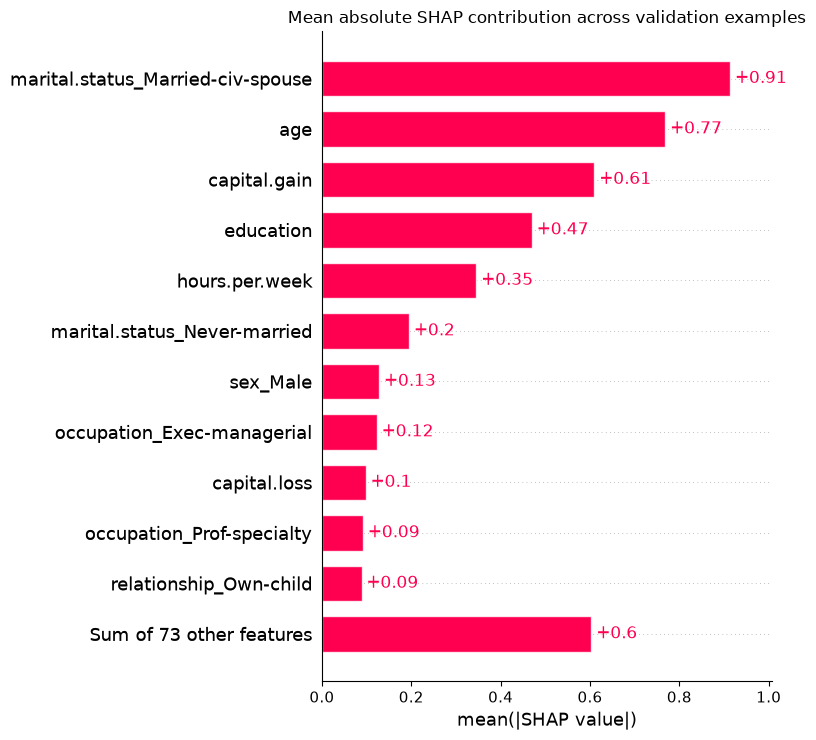

In [21]:
shap.plots.bar(shap_values, max_display=12, show=False)
plt.title("Mean absolute SHAP contribution across validation examples")
plt.tight_layout()
plt.show()

The `marital.status_Married-civ-spouse` indicator has the largest mean absolute contribution in this sample. The final bar groups the remaining features; it is not a single additional input. The positive bar lengths indicate magnitudes, not that every contribution pushes the output upward.

These bars do not measure a decrease in accuracy. Unlike permutation importance, this summary uses model outputs without comparing them with the observed labels. It describes the selected validation sample and reference, not every possible future population.

A **beeswarm plot** retains more detail. Each dot is one example's contribution for the feature on that row. Horizontal position gives the signed SHAP value; colour gives the transformed feature value, from low to high. Vertical spreading helps show where many dots overlap. The features are ordered by mean absolute contribution.

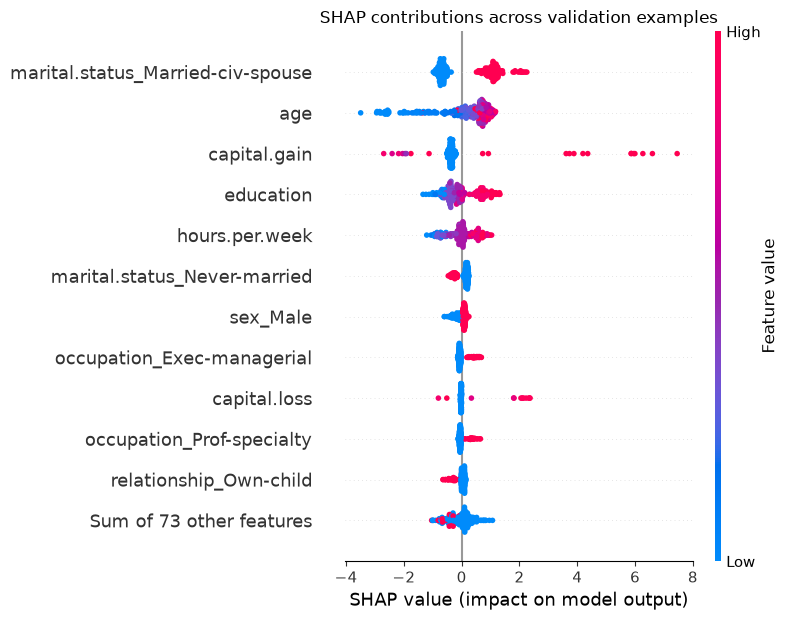

In [22]:
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP contributions across validation examples")
plt.tight_layout()
plt.show()

For the `marital.status_Married-civ-spouse` indicator, the red dots lie to the right and the blue dots to the left: presence and absence receive different contributions relative to this reference. For `capital.gain`, some high values receive large positive contributions, but others do not.

Look for other rows where high feature values tend to appear on the right and low values on the left. Those patterns describe the model's contributions in these examples. A mixture on both sides can reflect non-linear relationships and interactions with other inputs. For a one-hot feature, “high” means the category is present, not that the category itself has a high numerical value.

::: {.callout-note collapse="true" title="Optional: inspect one feature more closely"}
A SHAP scatter plot places a feature's value on the horizontal axis and its contribution on the vertical axis. For example:

```python
shap.plots.scatter(shap_values[:, "age"])
```

The age axis is standardized in this pipeline. A vertical spread at similar ages shows that age need not receive the same contribution for every person. This is a description of the explanations, not an estimate of what would happen if a person became older while everything else stayed unchanged.
:::

### Exercise 12.3: What does the explanation say?

A SHAP explanation for a binary classifier uses log-odds. Its base value is −1.0, and three displayed feature contributions are +0.8, +0.5, and −0.3. These are all the contributions.

1. What is the explained raw score, and what probability does it represent?
2. Does +0.8 mean that the feature adds 80 percentage points to the probability?
3. Does the explanation show that changing that feature would cause the real-world outcome to change?

::: {.callout-tip collapse="true" title="Solution"}
1. The raw score is $-1.0+0.8+0.5-0.3=0$, corresponding to probability $1/(1+e^0)=0.5$.
2. No. The contributions add in log-odds units. Convert the total score to a probability; an individual contribution is not a probability increment.
3. No. It allocates this model output relative to a chosen reference. It does not identify a causal effect or even, in general, the prediction change from editing that input alone.
:::

## Using explanations responsibly

Interpretation is most useful when it answers a concrete question. If a model depends heavily on a feature recorded after the outcome, the next step is to investigate leakage. If it relies on a measurement that will be unavailable at prediction time, revisit the feature set. If a particular prediction looks implausible, inspect the input record and the largest contributions before drawing conclusions.

An unexpected association is not automatically a mistake. Consider the feature's meaning, related inputs, missing-value handling, and representation. Comparing explanations across validation folds or reasonable modelling choices can help reveal whether a conclusion is stable. One fitted model's ranking is only one piece of evidence.

| Situation | Useful starting point | What to keep in mind |
|---|---|---|
| Understand an input change in a linear model | Coefficient calculation and a prediction check | Account for scaling, encoding, and the output scale. |
| Inspect which inputs a tree used during fitting | Impurity-based importance | Training splits can reward overfitting and favour features with many split points. |
| Investigate reliance on a feature for held-out performance | Permutation importance on a validation set | The metric, correlated inputs, and shuffling scheme affect the result. |
| Explain one prediction relative to a reference | SHAP waterfall plot | Identify the reference, units, and assumptions about missing features. |
| Summarize local contributions across examples | SHAP bar or beeswarm plot | The sample and transformed representation shape the summary. |

If explanations suggest removing or changing features, evaluate the revised pipeline using validation data or cross-validation. A low importance does not by itself justify deletion. Keep the test set for the final evaluation after those decisions.

Interpretation also does not replace a fairness assessment. A plausible explanation for one person does not tell us whether error rates differ across groups, and excluding a sensitive feature does not prevent related information from entering through other columns.

## Chapter summary

We started with a question that validation scores cannot answer by themselves: how does a fitted model use its inputs? Correlations describe associations in data. Coefficients describe a linear prediction rule in the transformed feature space. Tree importances summarize training splits, while permutation importance measures the effect of disrupting inputs on a chosen score. SHAP allocates an individual model output relative to a reference and can summarize those allocations across examples.

These methods are useful for checking a workflow, investigating surprising predictions, and communicating model behaviour. None assigns an intrinsic, permanent importance to a feature. Always state which model, data, representation, and question an explanation refers to—and distinguish the model's behaviour from causal claims about the world.